In [8]:
%load_ext autoreload
%autoreload 2

%autosave 120
import pandas as pd
from glob import glob
import numpy as np
from tqdm import tqdm
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef,  precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os
import math
from collections import Counter

random_seed = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Autosaving every 120 seconds


In [9]:
def plot_cdf(vals, labels, title):
    plt.figure(figsize=(20, 6))
    markers = ["o", "^", "D"]
    for values, marker, label in zip(vals,markers[:len(vals)], labels):
        values = np.array(values)
        sorted_values = np.sort(values)

        cdf_R = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
        
        plt.plot(sorted_values, cdf_R, marker=marker, label=label)
        
    plt.yticks(np.arange(0,1.1,0.1))
    plt.xticks(np.arange(0,1.1,0.1))
    plt.xlabel("Score")
    plt.ylabel("CDF")
    plt.title(title)
    plt.grid(True)
    plt.legend(loc="lower right")
    plt.show()

In [10]:
def undersample_by_iqr(df, y, p):
    # Combine features and labels
    df_copy = df.copy()
    df_copy["Label"] = y

    # Identify majority and minority classes
    class_counts = Counter(y)
    majority_class = max(class_counts, key=class_counts.get)
    minority_class = min(class_counts, key=class_counts.get)

    # Separate majority and minority samples
    majority_df = df_copy[df_copy["Label"] == majority_class]
    minority_df = df_copy[df_copy["Label"] == minority_class]

    # Only use numeric columns for outlier detection
    numeric_cols = majority_df.drop(columns=["Label"]).select_dtypes(include=[np.number]).columns

    # Create outlier mask for majority class
    outlier_mask = pd.DataFrame(False, index=majority_df.index, columns=numeric_cols)
    for col in numeric_cols:
        Q1 = majority_df[col].quantile(0.25)
        Q3 = majority_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_mask[col] = (majority_df[col] < lower_bound) | (majority_df[col] > upper_bound)

    # Count how many columns mark each row as an outlier
    outlier_counts = outlier_mask.sum(axis=1)
    threshold = math.ceil(p / 100 * len(numeric_cols))

    # Keep only majority rows with fewer than threshold outlier columns
    majority_filtered = majority_df[outlier_counts < threshold]

    # Concatenate with all minority samples (not undersampled)
    balanced_df = pd.concat([majority_filtered, minority_df], axis=0).sample(frac=1, random_state=42)

    # Split back into features and labels
    return balanced_df.drop(columns=["Label"]), balanced_df["Label"]


In [11]:
apply_scaling = False
apply_sampling = True

Sampler = RandomUnderSampler
Scaler = StandardScaler

def train_evaluate(DATA_DIR, y_col = "Detection"):
    csv_files = sorted(glob(os.path.join(DATA_DIR, '*.csv')))

    # Ensure there are exactly 49 CSV files
    assert len(csv_files) == 49, f"Expected 49 CSV files, found {len(csv_files)}"

    columns = ['SLOCStandard', 'Readability', 'McCabe', 'totalFanOut', 'MaintainabilityIndex'] 
    # columns = ['SLOCStandard', 'Readability', 'SimpleReadability', 'NVAR',
    #    'NCOMP', 'Mcclure', 'McCabe', 'IndentSTD', 'MaximumBlockDepth',
    #    'totalFanOut', 'Length', 'MaintainabilityIndex', 'SATD', 'Parameters',
    #    'LocalVariables'] 
    # To collect accuracy or any metrics
    results = []

    # Leave-One-Out Cross-Validation
    for i in tqdm(range(len(csv_files))):
        # Split train and test sets
        test_file = csv_files[i]
        train_files = csv_files[:i] + csv_files[i+1:]

        # Load data
        train_df = pd.concat([pd.read_csv(f) for f in train_files], ignore_index=True)
        test_df = pd.read_csv(test_file)

        X_train, y_train = train_df[columns], train_df[y_col]
        X_test, y_test = test_df[columns], test_df[y_col]
        
        X_train = X_train / X_train.mean()
        X_test = X_test / X_test.mean()

        if apply_scaling:
            scaler = Scaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # Apply random oversampling
        if apply_sampling:
            #X_train, y_train = undersample_by_iqr(X_train, y_train, 50)
            ros = Sampler(random_state=random_seed)
            X_train, y_train = ros.fit_resample(X_train, y_train)

        # Train model
        model = RandomForestClassifier(random_state=random_seed, n_jobs=-1)
        #model = MLPClassifier(random_state=random_seed)
        model.fit(X_train, y_train)

        # Evaluate
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if len(model.classes_) == 2 else None

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0, pos_label="Buggy")
        rec = recall_score(y_test, y_pred, zero_division=0, pos_label="Buggy")
        f1 = f1_score(y_test, y_pred, zero_division=0, pos_label="Buggy")
        mcc = matthews_corrcoef(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float('nan')

        results.append({
            'test_file': os.path.basename(test_file),
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1,
            'mcc': mcc,
            'auc': auc
        })

    # Save results to CSV
    results = pd.DataFrame(results)
    return  results


# Noise-Free Dataset

In [12]:
results_noise_free = train_evaluate('./data/NoiseFreeDataset/', "Detection")
results_noise_free

100%|██████████| 49/49 [02:02<00:00,  2.50s/it]


,test_file,accuracy,precision,recall,f1_score,mcc,auc
0,Essentials.csv,0.667238,0.149231,0.769841,0.250000,0.229595,0.781389
1,RxJava.csv,0.585698,0.536199,0.596977,0.564958,0.172577,0.612601
2,ant.csv,0.673464,0.050878,0.713568,0.094983,0.125050,0.763040
3,argouml.csv,0.605743,0.125161,0.729323,0.213656,0.171489,0.715876
4,atmosphere.csv,0.672571,0.076285,0.741935,0.138346,0.160249,0.766291
5,cassandra.csv,0.633625,0.028251,0.617021,0.054029,0.067091,0.667046
6,checkstyle.csv,0.685849,0.325700,0.653061,0.434635,0.278380,0.721263
7,commons-io.csv,0.612565,0.132530,0.846154,0.229167,0.224398,0.826059
8,commons-lang.csv,0.649215,0.063877,0.734177,0.117528,0.138697,0.716117
9,cucumber-jvm.csv,0.625000,0.110000,0.611111,0.186441,0.124282,0.663749


# Noisy Dataset

In [13]:
results_noisy = train_evaluate('./data/NoisyDataset/', "Decision")
results_noisy

  0%|          | 0/49 [00:00<?, ?it/s]

  2%|▏         | 1/49 [00:02<02:18,  2.89s/it]/home/cs/grad/opumni/.local/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
100%|██████████| 49/49 [02:23<00:00,  2.92s/it]


,test_file,accuracy,precision,recall,f1_score,mcc,auc
0,Essentials.csv,0.640366,0.175414,0.798742,0.287656,0.247049,0.790521
1,RxJava.csv,0.517594,1.000000,0.517594,0.682124,0.000000,NaN
2,ant.csv,0.637263,0.060995,0.701107,0.112227,0.123458,0.723225
3,argouml.csv,0.498343,0.236585,0.658073,0.348044,0.093909,0.610590
4,atmosphere.csv,0.637143,0.088921,0.859155,0.161162,0.196775,0.785113
5,cassandra.csv,0.582935,0.027265,0.577273,0.052071,0.045299,0.634177
6,checkstyle.csv,0.618868,0.403423,0.507692,0.449591,0.166438,0.616532
7,commons-io.csv,0.685864,0.250000,0.863636,0.387755,0.343305,0.832302
8,commons-lang.csv,0.563029,0.058192,0.663265,0.106996,0.086956,0.660754
9,cucumber-jvm.csv,0.617188,0.169811,0.642857,0.268657,0.162779,0.640508


# Comparison

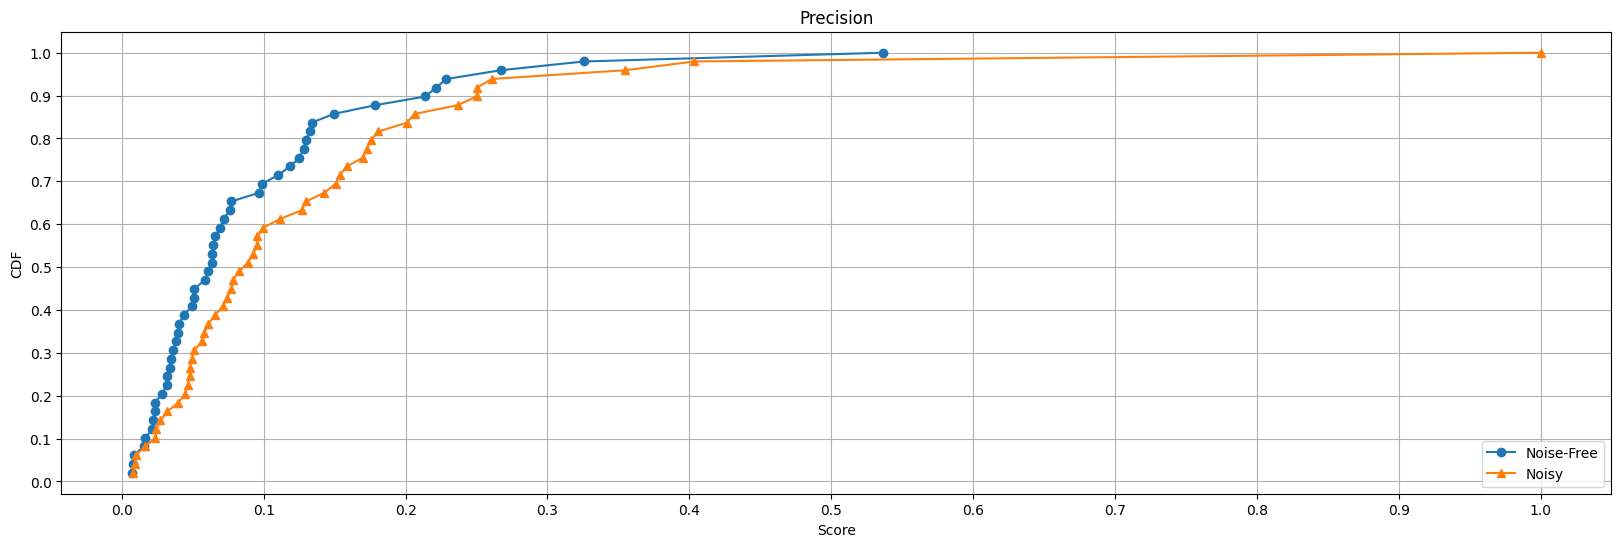

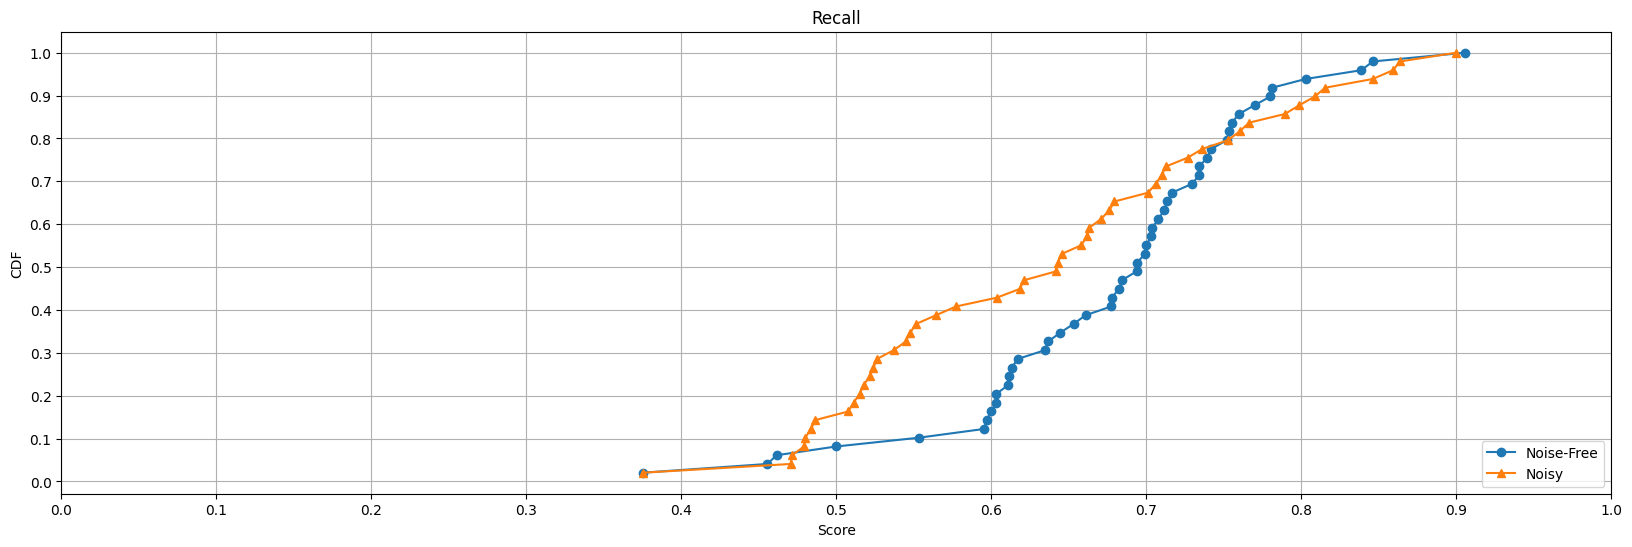

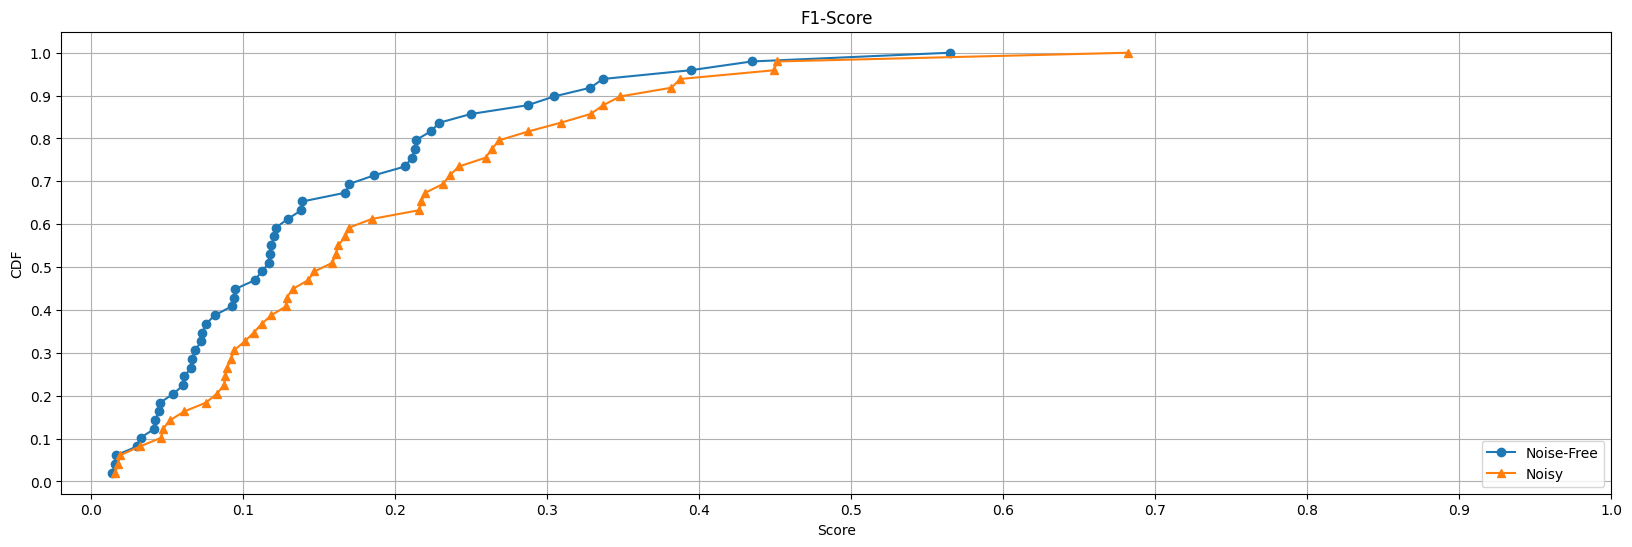

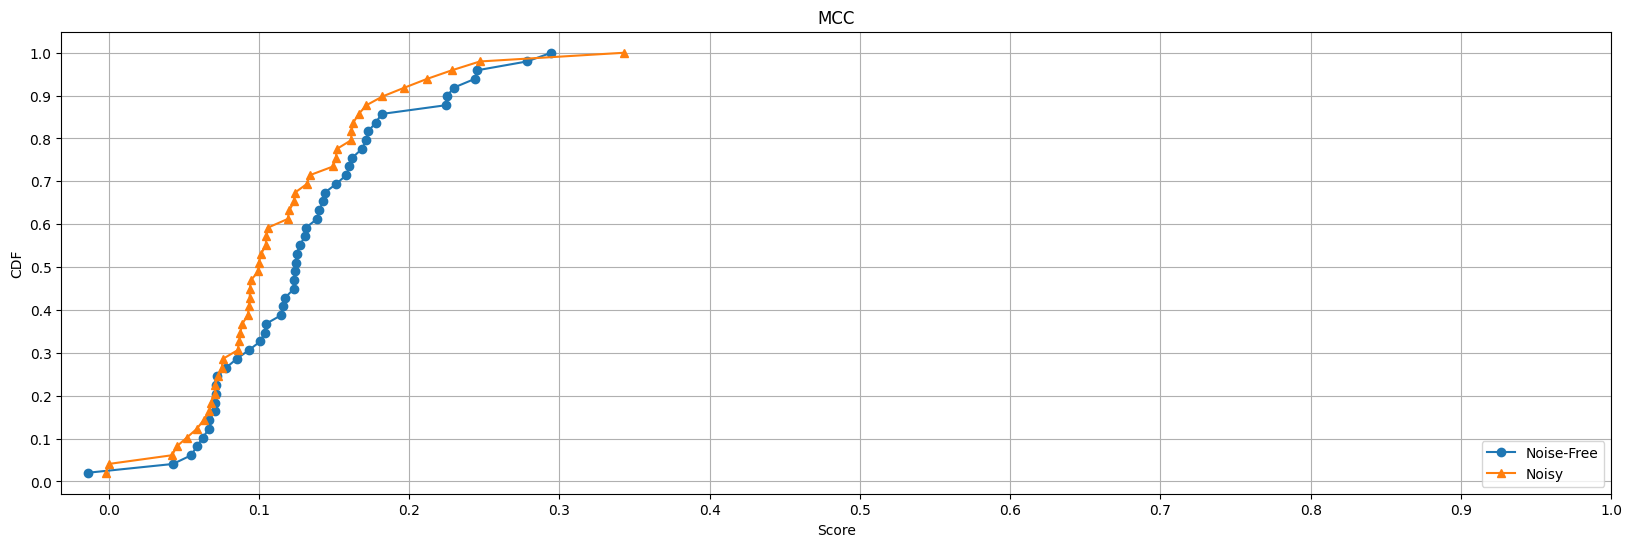

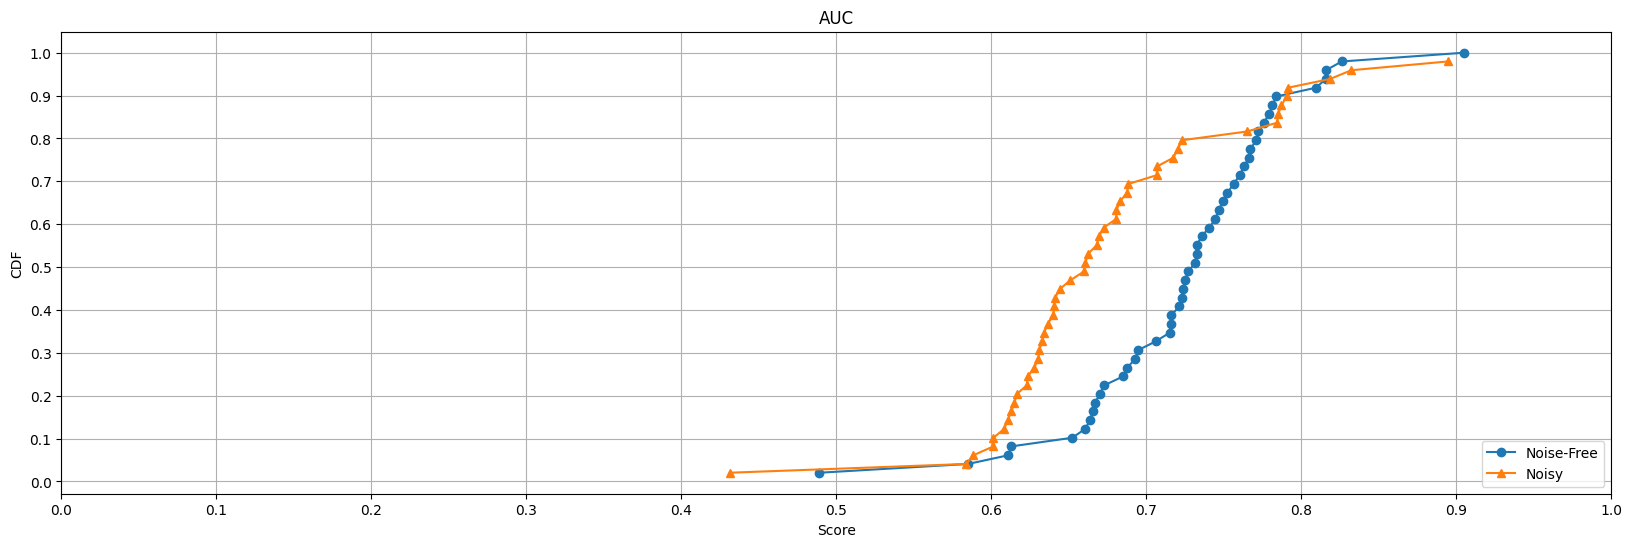

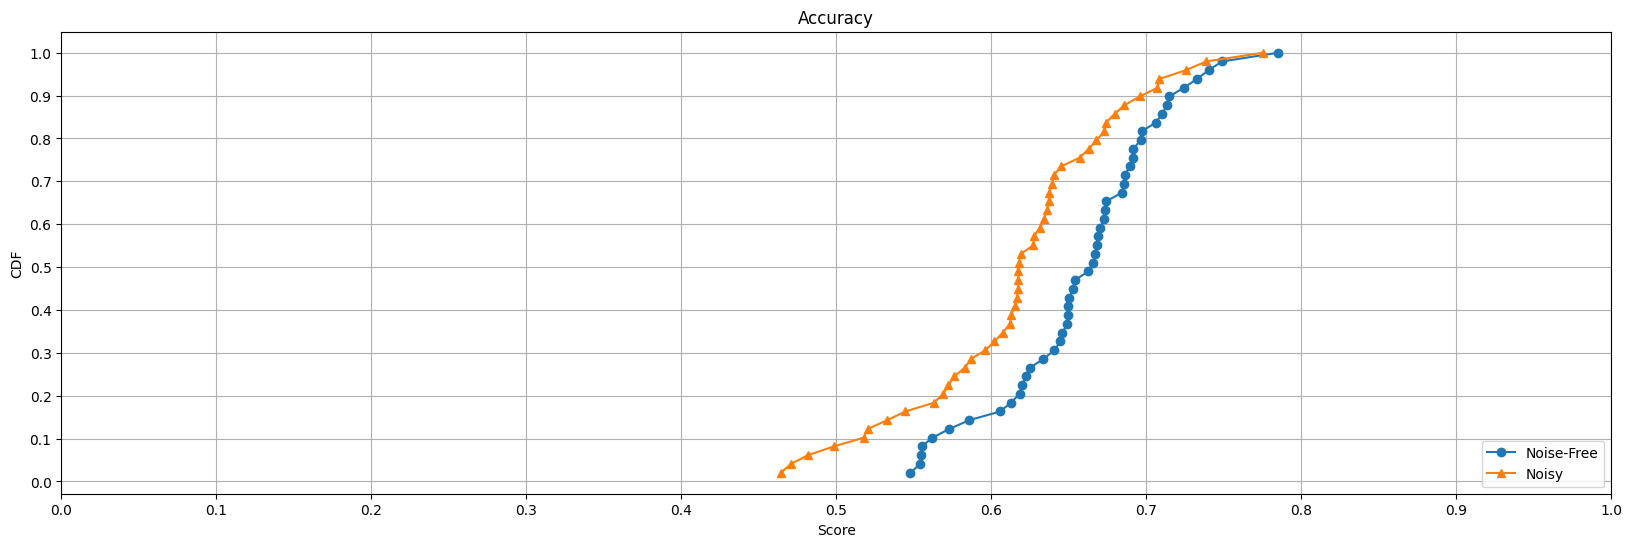

In [14]:
plot_cdf([results_noise_free["precision"], results_noisy["precision"]], ["Noise-Free", "Noisy"], "Precision")
plot_cdf([results_noise_free["recall"], results_noisy["recall"]], ["Noise-Free", "Noisy"], "Recall")
plot_cdf([results_noise_free["f1_score"], results_noisy["f1_score"]], ["Noise-Free", "Noisy"], "F1-Score")
plot_cdf([results_noise_free["mcc"], results_noisy["mcc"]], ["Noise-Free", "Noisy"], "MCC")
plot_cdf([results_noise_free["auc"], results_noisy["auc"]], ["Noise-Free", "Noisy"], "AUC")
plot_cdf([results_noise_free["accuracy"], results_noisy["accuracy"]], ["Noise-Free", "Noisy"], "Accuracy")